<a href="https://colab.research.google.com/github/dragisamitpredavanja/ai-prvi/blob/main/prepoznavanje_slika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from google.colab import files  # Za preuzimanje na računar

# 1. Podaci
x_podaci = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)
y_podaci = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0], dtype=float)

# 2. Model
model = keras.Sequential([keras.layers.Dense(units=1, input_shape=(1,))])

# 3. Kompajliranje
model.compile(optimizer='sgd', loss='mean_squared_error')

# 4. Treniramo AI
print("Treniranje je počelo...")
model.fit(x_podaci, y_podaci, epochs=500, verbose=0)
print("Treniranje završeno!")

# 5. Predikcija
rezultat = model.predict(np.array([10.0]))
# ISPRAVLJENO: Dodato [0][0] da bismo izvukli čist broj iz NumPy polja
print(f"Za X = 10, AI predviđa da je Y = {rezultat[0][0]:.4f}")

# 6. Čuvanje i preuzimanje
naziv_fajla = "moj_prvi_model.keras"
model.save(naziv_fajla)
print(f"\nModel uspešno napravljen i sačuvan!")
files.download(naziv_fajla)


Treniranje je počelo...
Treniranje završeno!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Za X = 10, AI predviđa da je Y = 18.9799

Model uspešno napravljen i sačuvan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from google.colab import files

# 1. Učitavamo MNIST bazu podataka sa slikama brojeva
mnist = keras.datasets.mnist
(x_trening, y_trening), (x_test, y_test) = mnist.load_data()

# 2. Normalizacija podataka (Prebacujemo vrednosti piksela na opseg od 0 do 1)
x_trening, x_test = x_trening / 255.0, x_test / 255.0

# 3. Pravimo modernu neuronsku mrežu za prepoznavanje slika (Keras 3 standard)
model = keras.Sequential([
    # ISPRAVLJENO: Koristimo Input sloj na početku kako bismo uklonili User Warning
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    # Glavni skriveni sloj sa 128 neurona
    keras.layers.Dense(128, activation='relu'),
    # Izlazni sloj sa 10 neurona (za brojeve od 0 do 9)
    keras.layers.Dense(10, activation='softmax')
])

# 4. Konfigurišemo model
# ISPRAVLJENO: 'sparse_categorical_entropy' zamenjeno sa 'sparse_categorical_crossentropy'
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Treniramo AI kroz 5 epoha
print("Treniranje na slikama je počelo...")
model.fit(x_trening, y_trening, epochs=5, batch_size=64)
print("Treniranje završeno!")

# 6. Proveravamo tačnost modela na test podacima
gubitak, tacnost = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTačnost modela na test podacima je: {tacnost * 100:.2f}%")

# 7. Testiramo AI na jednoj konkretnoj slici iz test skupa (indeks 0)
slika_za_test = x_test[0]
pravi_odgovor = y_test[0]

# AI daje predikciju
predikcija = model.predict(slika_za_test[np.newaxis, ...], verbose=0)
pogodjeni_broj = np.argmax(predikcija)

print(f"\n[AI PREDVIĐA]: Na slici je broj {pogodjeni_broj}")
print(f"[TAČAN ODGOVOR]: Na slici je zapravo broj {pravi_odgovor}")

# 8. Čuvanje modela za prepoznavanje slika na tvoj računar
naziv_modela = "model_za_slike.keras"
model.save(naziv_modela)
print(f"\nPreuzimam model za slike na tvoj računar...")
files.download(naziv_modela)


Treniranje na slikama je počelo...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9170 - loss: 0.3000
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9618 - loss: 0.1300
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9739 - loss: 0.0901
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9797 - loss: 0.0690
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9844 - loss: 0.0540
Treniranje završeno!

Tačnost modela na test podacima je: 97.60%

[AI PREDVIĐA]: Na slici je broj 7
[TAČAN ODGOVOR]: Na slici je zapravo broj 7

Preuzimam model za slike na tvoj računar...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

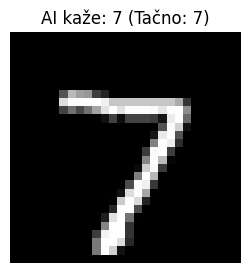

In [23]:
# Prikazujemo samo PRVU sliku (indeks 0) iz test skupa
plt.figure(figsize=(3,3))
plt.imshow(x_test[0], cmap='gray')  # ISPRAVLJENO: Dodat indeks [0]
plt.title(f"AI kaže: {pogodjeni_broj} (Tačno: {pravi_odgovor})") # ISPRAVLJENO: Dodato slovo f
plt.axis('off')
plt.show()
